In [91]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from typing_extensions import Annotated
import operator

In [92]:
def my_choice(existing,new):
    return new

In [93]:
def enroute(state):
    comments = state["comments"].lower()

    if "money" in comments:
        return "marketing_response"
    else:
        return "finance_response"

In [94]:
class Customerconcern(TypedDict):
    concern: Annotated[str, my_choice]
    comments: Annotated[str,my_choice] 
    response: Annotated[list[str],my_choice]

In [95]:
def analyze_sentiment(state:Customerconcern):
    return{"comments": f"{state['comments']}\nCustomer is furios"}

 

In [96]:
def marketing_response(state:Customerconcern):
    return{"response": "we are extremely sorry our executive will reach out"}


In [97]:
marketing_graph_builder = StateGraph(Customerconcern)
marketing_graph_builder.add_node("sentiment",analyze_sentiment)
marketing_graph_builder.add_node("response",marketing_response)
marketing_graph_builder.set_entry_point("sentiment")
marketing_graph_builder.add_edge("sentiment","response")
marketing_graph_builder.set_finish_point("response")


In [98]:
def analyze_facts(state:Customerconcern):
    return {"comments": f"{state['comments']}\nCustomer is genuine"}
def fin_response(state:Customerconcern):
    return {"response": "your money is safe wiyh us"}

In [99]:
finance_graph_builder = StateGraph(Customerconcern)
finance_graph_builder.add_node("facts", analyze_facts)
finance_graph_builder.add_node("fresponse", fin_response)
finance_graph_builder.set_entry_point("facts")
finance_graph_builder.add_edge("facts","fresponse")
finance_graph_builder.set_finish_point("fresponse")

In [100]:
def init(state:Customerconcern):
    return state

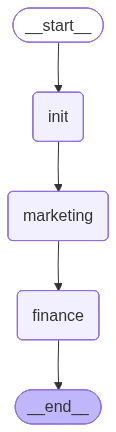

In [101]:
customer_care_graph = StateGraph(Customerconcern)
marketing_graph = marketing_graph_builder.compile()
finance_graph = finance_graph_builder.compile()

customer_care_graph.add_node("init", init)
customer_care_graph.add_node("marketing",marketing_graph)
customer_care_graph.add_node("finance",finance_graph)
customer_care_graph.set_entry_point("init")
customer_care_graph.add_edge("init","marketing")
customer_care_graph.add_edge("marketing","finance")
customer_care_graph.set_finish_point("finance")

cc_graph = customer_care_graph.compile()
cc_graph

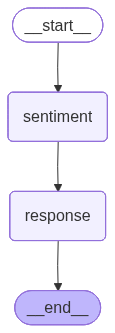

In [102]:
marketing_graph

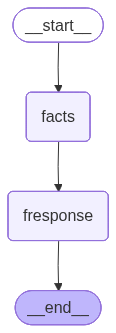

In [103]:
finance_graph

In [104]:
response = cc_graph.invoke({
    "concern": "Im sleepy",
    "comments": "",
    "response":""
    })
response

{'concern': 'Im sleepy',
 'comments': '\nCustomer is furios\nCustomer is genuine',
 'response': 'your money is safe wiyh us'}

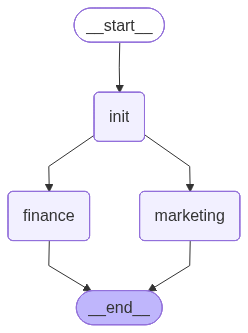

In [105]:
customer_care_parallel_graph = StateGraph(Customerconcern)
customer_care_parallel_graph.add_node("init",init)
customer_care_parallel_graph.add_node("marketing", marketing_graph)
customer_care_parallel_graph.add_node("finance", finance_graph)
customer_care_parallel_graph.set_entry_point("init")
customer_care_parallel_graph.add_conditional_edges(
    "init", enroute)
customer_care_parallel_graph.add_edge("init","marketing")
customer_care_parallel_graph.add_edge("init","finance")
customer_care_parallel_graph.add_edge("init","marketing")
customer_care_parallel_graph.set_finish_point("finance")
customer_care_parallel_graph.set_finish_point("marketing")

cc_parallel_graph = customer_care_parallel_graph.compile()
cc_parallel_graph

In [106]:
response = cc_parallel_graph.invoke({
    "concern": "Im sleepy",
    "comments": "",
    "response":""
    })
response

Task init with path ('__pregel_pull', 'init') wrote to unknown channel branch:to:finance_response, ignoring it.


{'concern': 'Im sleepy',
 'comments': '\nCustomer is furios',
 'response': 'we are extremely sorry our executive will reach out'}